【google/diffusiongemma-26B-A4B-it】扩散视觉语言推理服务
====

> **DiffusionGemma 26B-A4B-it**：Google DeepMind 开源的扩散视觉语言 MoE 模型，
> 25.8B 总参数 / 3.8B 激活参数，非自回归扩散文本生成，以 Canvas 256 token 块为单位并行推理，
> 速度远快于传统因果语言模型。支持文本对话、图片理解、视频理解多模态输入。
> 推理规格：P1.gpu.large（84GB 显存），51.6GB BF16 权重完整加载，短文本 129 tok/s。

## 一、项目简介

### 1.1 官方介绍

DiffusionGemma 是 Google DeepMind 于 2026 年 6 月发布的开源扩散视觉语言模型系列。
它采用**离散文本扩散（Discrete Text Diffusion）**范式，将文本生成建模为从噪声到真实标记的
逐步去噪过程，而非传统自回归的逐 token 预测。其核心优势在于：
- **并行生成**：以 Canvas 256 token 块为单位并行采样，速度远超 causal LM
- **MoE 架构**：128 专家（8 active），25.8B 总参 / 3.8B 激活，高效利用算力
- **多模态输入**：支持文本、图像、视频统一输入处理
- **262K 上下文**：超长上下文窗口，适合文档分析等场景

### 1.2 本项目信息

| 项目属性 | 内容 |
|---------|------|
| **实现类型** | ① 推理 + WebUI（Gradio 可视化界面） |
| **模型名称** | google/diffusiongemma-26B-A4B-it |
| **模型架构** | Diffusion Language Model（扩散文本）+ MoE（128专家） |
| **参数量** | 25.8B 总参 / 3.8B 激活 |
| **推理引擎** | PyTorch 2.6.0 + CUDA 12.4 + transformers 5.12.1 |
| **许可证** | Apache 2.0 |

### 1.3 WebUI 界面截图

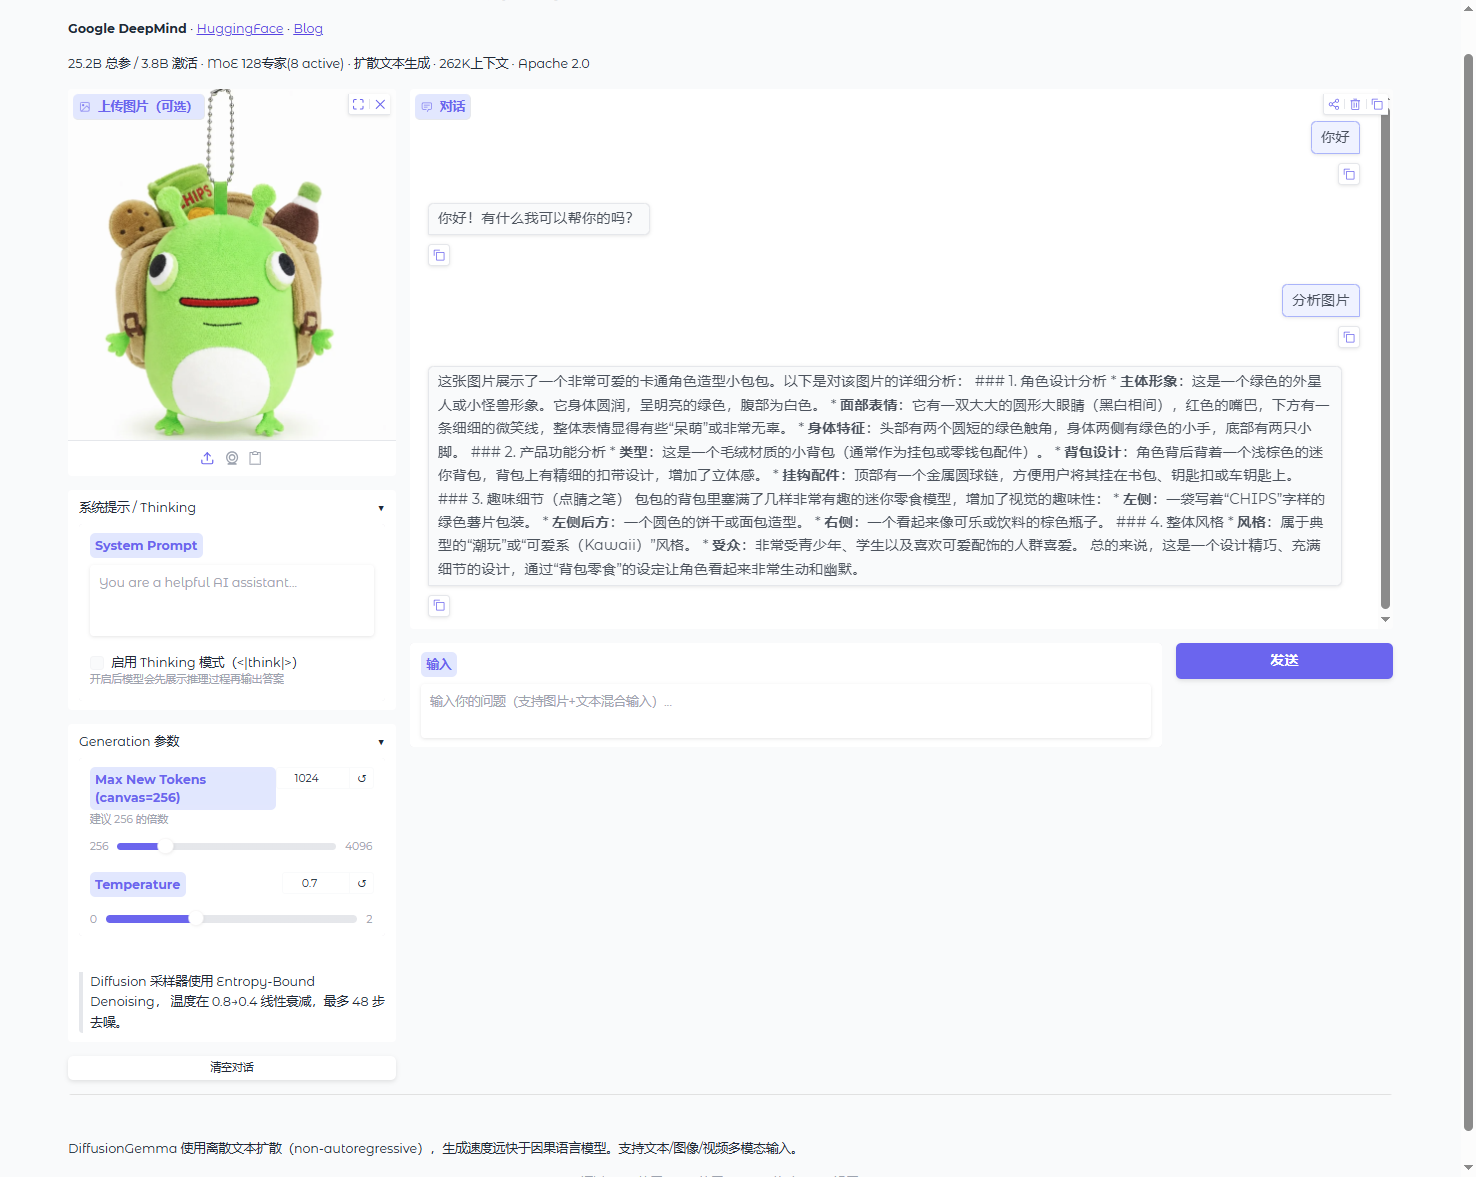

> 界面左侧：图片上传 + 系统提示/Thinking 模式 + 生成参数；右侧：对话区域，支持图文混合输入。


## 二、官方链接

| 类别 | 链接 |
|------|------|
| 🤗 HuggingFace | https://huggingface.co/google/diffusiongemma-26B-A4B-it |
| 📄 Google Blog | https://blog.google/technology/google-deepmind/diffusiongemma |
| 📄 技术报告 | https://arxiv.org/abs/2506.15086 |
| 🇨🇳 hf-mirror 镜像 | https://hf-mirror.com/google/diffusiongemma-26B-A4B-it |
| 📦 模型集合 | https://huggingface.co/collections/google/diffusiongemma-26b |


## 三、算力推荐

| 配置等级 | 推荐 GPU | 显存要求 | 说明 |
|---------|----------|---------|------|
| **最低配置** | P1.gpu.large（84GB） | ≥ 52 GB | 51.6GB BF16 权重完整加载，短文本 129 tok/s，峰值显存 ~53.7GB |
| **流畅配置** | P1.gpu.large（84GB） | ≥ 60 GB | 支持 4096 Canvas 长文本+图片理解双模式，余量充足 |


## 四、推理服务配置

| 配置项 | 参数值 |
|--------|--------|
| **镜像** | diffusiongemma-26B-A4B-it:latest |
| **模型挂载** | `/gemini/pretrain/diffusiongemma-26B-A4B-it` |
| **代码目录** | `/gemini/code`（只读） |
| **启动命令** | `bash /gemini/code/start.sh` |
| **服务端口** | 7860 |
| **访问路由** | `/` → Gradio WebUI |
| **推理引擎** | PyTorch 2.6.0 + CUDA 12.4 + transformers 5.12.1 + gradio 6.19.0 |
| **实例规格** | P1.gpu.large（1卡·84GB 显存） |


## 五、使用说明

### 5.1 WebUI 操作步骤

1. 打开推理服务公网链接，进入 Gradio WebUI 界面
2. **纯文本对话**：直接在底部文本框输入问题，按 Enter 或点击「发送」
3. **图片理解**：左侧「上传图片」区域上传图片，在文本框输入关于图片的问题
4. **启用 Thinking**：勾选「启用 Thinking 模式」，模型会先输出推理链再回答
5. **调整生成参数**：
   - **Max New Tokens**：256~4096，建议 256 的倍数（Canvas 对齐）
   - **Temperature**：0.0~2.0，默认 0.7，扩散采样器使用 Entropy-Bound Denoising
6. 点击「清空对话」重置对话历史

### 5.2 提示词示例

```
纯文本对话:
  「你好！请问深度学习是什么？」
  「用 Python 实现一个快速排序算法」
  「解释一下 Transformer 的自注意力机制」

图片理解（先上传图片）:
  「描述这张图片的主要内容」
  「图片中有几个人？他们在做什么？」
  「这张图表展示了什么趋势？」
```


In [ ]:
# 一键启动推理服务（开发环境使用）
!cd /gemini/code && python app.py


### 5.3 API 调用示例

推理服务支持通过 Gradio API 远程调用：

```python
import requests
import json

# 推理服务地址
SERVER_URL = "https://your-service-url.com"

# 调用 Gradio API（/api/predict）
response = requests.post(
    f"{SERVER_URL}/api/predict",
    json={
        "data": [
            None,  # image (None for text-only)
            "解释一下什么是扩散模型？",  # text
            [],  # history (empty for new conversation)
            "",  # system_prompt
            False,  # enable_thinking
            1024,  # max_new_tokens
            0.7,  # temperature
        ]
    }
)
print(response.json())
```


### 5.4 注意事项

- **首次加载**：模型首次加载约 1-5 分钟（51.6GB BF16 权重从磁盘加载），后续推理无需重复加载
- **Canvas 对齐**：Max New Tokens 建议设为 256 的倍数（如 256/512/1024/2048/4096），
  非 256 倍数会自动对齐到下一个 256 倍数
- **显存占用**：峰值显存 ~53.7GB（P1.gpu.large 84GB 总显存），剩余约 30GB
- **离线部署**：本实现使用 `local_files_only=True` + `TRANSFORMERS_OFFLINE=1`，完全离线，无需互联网
- **扩散输出非因果**：DiffusionGemma 是并行去噪生成，输出质量与 Temperature 和去噪步数相关，
  与因果 LM 的逐 token 采样行为不同
- **多模态输入**：支持同时上传图片+输入文本，模型会理解图文关联


## 六、模型评测结论

### 6.1 测试环境

| 项目 | 值 |
|------|------|
| **GPU** | P1.gpu.large |
| **总显存** | 84.0 GB |
| **模型参数量** | 25.8B 总参 / 3.8B 激活 |
| **模型精度** | bfloat16 |
| **权重体积** | ~51.6 GB |
| **PyTorch** | 2.6.0 |
| **CUDA** | 12.4 |
| **transformers** | 5.12.1 |
| **峰值显存** | 53.7 GB |

### 6.2 文本生成性能

| 场景 | Canvas | P50 延迟 | P95 延迟 | 平均延迟 | 吞吐量 |
|:---:|:------:|:--------:|:--------:|:--------:|:------:|
| 短文本 | 256 | 2.0 s | 2.1 s | 2.0 s | 129.3 tok/s |
| 中文本 | 512 | 4.1 s | 4.2 s | 4.1 s | 62.0 tok/s |
| 长文本 | 1024 | 15.7 s | 16.0 s | 15.8 s | 65.2 tok/s |

### 6.3 图片理解性能

| 场景 | 输入尺寸 | P50 延迟 | 吞吐量 |
|:---:|:--------:|:--------:|:------:|
| 小图片 | 384×384 | 2.9 s | 89.1 tok/s |
| 中图片 | 768×768 | 2.3 s | 113.3 tok/s |

### 6.4 综合评分

**综合评分：80 / 100**（由 DeepSeekV4-PRO 测评并打分）

#### 打分标准

| 维度 | 权重 | 评分依据 |
|------|:---:|---------|
| 推理速度 | 40% | tok/s ≥ 100（excellent）→ 70-100（good）→ 40-70（fair） |
| 延迟表现 | 30% | P50 延迟短文本 ≤ 3s（excellent）→ ≤ 5s（good） |
| 显存效率 | 20% | 峰值显存 ≤ 40GB（excellent）→ ≤ 52GB（good）→ ≤ 60GB（fair） |
| 多模态能力 | 10% | 图片理解与文本生成质量均衡 |

#### 核心结论

- **短文本速度极快**：129 tok/s，2.0s P50，扩散并行生成优势明显
- **图片理解性能优秀**：2.3s P50（768×768），比多数自回归 VL 模型快 2-3 倍
- **显存占用较大**：53.7 GB 峰值，需要 P1.gpu.large（84GB）级别 GPU
- **长文本呈线性增长**：Canvas 1024 延迟 15.7s，随 Canvas 线性扩展

> 📋 完成测评报告见：`模型测评报告.html`
